# German Electricity Demand Forecasting

## Part 1: Data Preparation and Exploratory Data Analysis

This notebook loads the German electricity demand dataset from the Open Power System Data project, filters the study period (2015–2020), creates daily and weekly aggregated series, and performs an initial exploratory analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

In [3]:
filepath = "/content/drive/MyDrive/time_series_60min_singleindex.csv"
df = pd.read_csv(filepath)
df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [4]:
# Convert timestamp and inspect dataset

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
print("Shape:", df.shape)
df.info()

Shape: (50401, 300)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Columns: 300 entries, utc_timestamp to UA_load_forecast_entsoe_transparency
dtypes: datetime64[ns, UTC](1), float64(298), object(1)
memory usage: 115.4+ MB


In [5]:
# Select German electricity demand column
electricity = df[[
    "utc_timestamp",
    "DE_load_actual_entsoe_transparency"
]].copy()

In [6]:
# Rename columns

electricity.columns = ["timestamp", "load"]

electricity.head()

,timestamp,load
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,41151.0
2,2015-01-01 01:00:00+00:00,40135.0
3,2015-01-01 02:00:00+00:00,39106.0
4,2015-01-01 03:00:00+00:00,38765.0


In [7]:
# Filter data from 2015 onwards

electricity["timestamp"] = pd.to_datetime(
    electricity["timestamp"]
)

electricity = electricity[
    electricity["timestamp"] >= "2015-01-01"
]

electricity.head()

,timestamp,load
1,2015-01-01 00:00:00+00:00,41151.0
2,2015-01-01 01:00:00+00:00,40135.0
3,2015-01-01 02:00:00+00:00,39106.0
4,2015-01-01 03:00:00+00:00,38765.0
5,2015-01-01 04:00:00+00:00,38941.0


In [8]:
# Set timestamp as index

electricity.set_index(
    "timestamp",
    inplace=True
)

electricity.head()

,load
timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


In [9]:
# Check missing values

electricity.isnull().sum()

,0
load,0


In [10]:
# Summary statistics

electricity.describe()

,load
count,50400.000000
mean,55492.468552
std,10015.431042
min,31307.000000
25%,47106.000000
50%,55092.000000
75%,64309.250000
max,77549.000000


In [11]:
# Create daily time series

daily_load = (
    electricity
    .resample("D")
    .mean()
)

daily_load.head()

,load
timestamp,
2015-01-01 00:00:00+00:00,45346.541667
2015-01-02 00:00:00+00:00,51941.166667
2015-01-03 00:00:00+00:00,46564.750000
2015-01-04 00:00:00+00:00,45082.500000
2015-01-05 00:00:00+00:00,55246.666667


In [12]:
# Create weekly time series

weekly_load = (
    electricity
    .resample("W")
    .mean()
)

weekly_load.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


In [13]:
# Check series dimensions

print("Hourly observations:", len(electricity))
print("Daily observations:", len(daily_load))
print("Weekly observations:", len(weekly_load))

Hourly observations: 50400
Daily observations: 2100
Weekly observations: 301


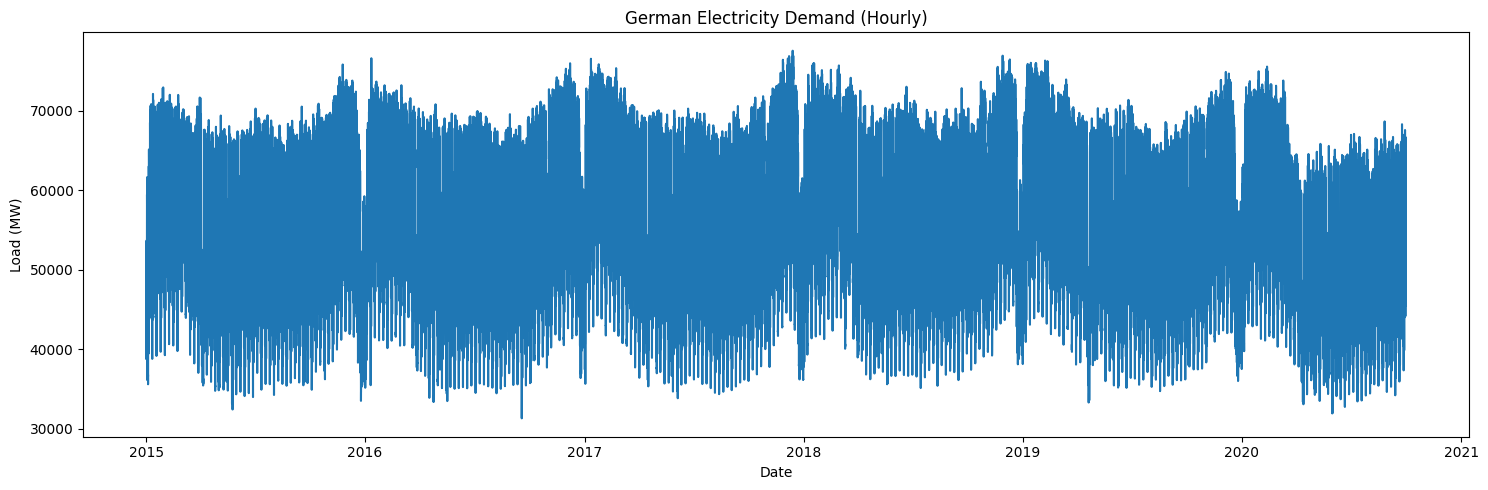

In [14]:
# Plot hourly electricity demand

plt.figure(figsize=(15,5))

plt.plot(
    electricity.index,
    electricity["load"]
)

plt.title("German Electricity Demand (Hourly)")
plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.tight_layout()

plt.savefig(
    "hourly_load.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

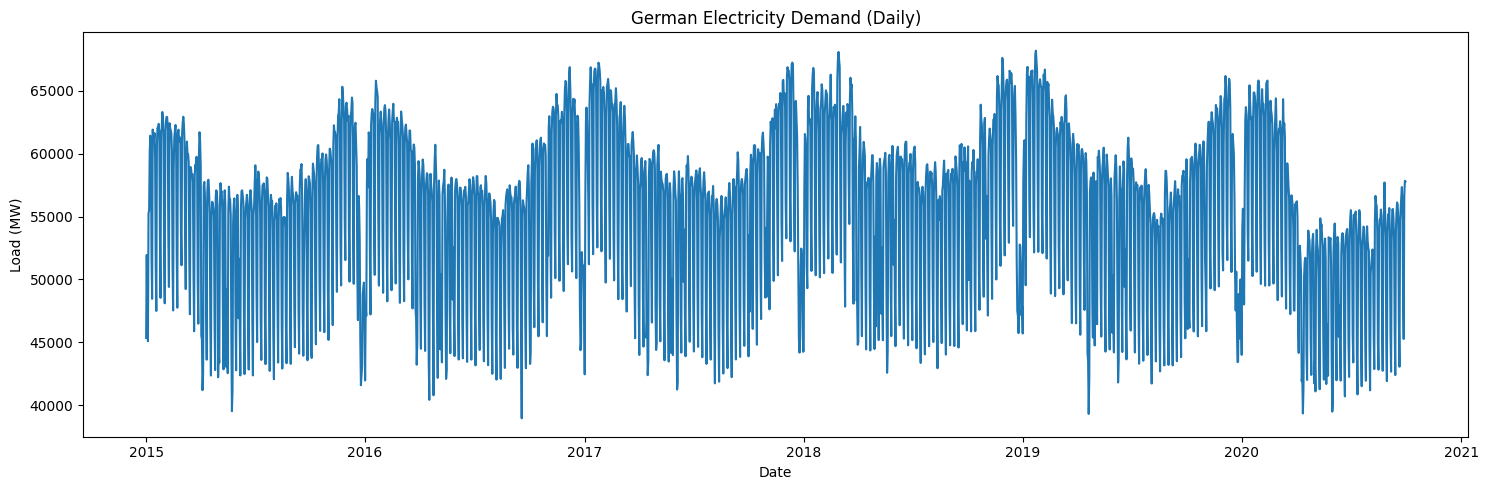

In [15]:
# Plot weekly electricity demand

plt.figure(figsize=(15,5))

plt.plot(
    daily_load.index,
    daily_load["load"]
)

plt.title("German Electricity Demand (Daily)")
plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.tight_layout()

plt.savefig(
    "daily_load.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

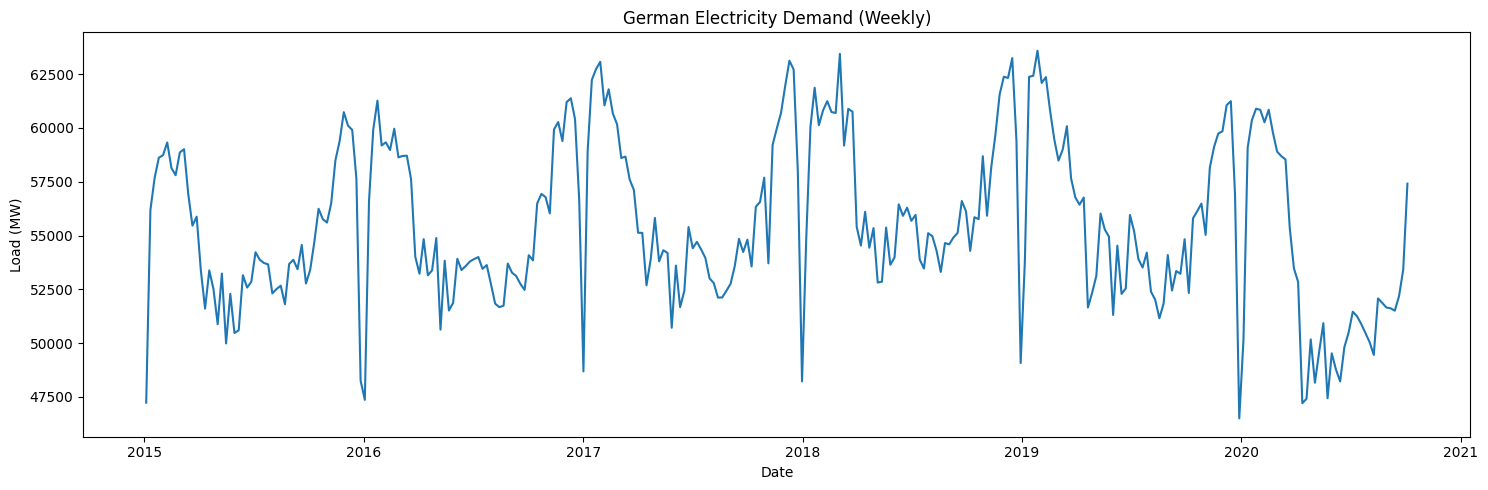

In [16]:
# Plot weekly electricity demand

plt.figure(figsize=(15,5))

plt.plot(
    weekly_load.index,
    weekly_load["load"]
)

plt.title("German Electricity Demand (Weekly)")
plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.tight_layout()

plt.savefig(
    "weekly_load.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# Save processed datasets

daily_load.to_csv("daily_load.csv")
weekly_load.to_csv("weekly_load.csv")